# Lecture 10 - The Naive Bayes Classifier

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('bmh')
import scipy.stats as stats
import pandas as pd

In [2]:
def generateData(mean1, mean2, cov1, cov2, N1, N2):
    # We are generating data from two Gaussians to represent two classes
    # In practice, we would not do this - we would just have data from the problem we are trying to understand
    data_C1 = stats.multivariate_normal(mean1, cov1).rvs(size=N1)
    data_C2 = stats.multivariate_normal(mean2, cov2).rvs(size=N2)
        
    # Entire Training Dataset
    data = np.concatenate((data_C1, data_C2))
    labels = np.concatenate((np.ones(N1),2*np.ones(N2)))
    
    if len(mean1)>1:
        plt.scatter(data[labels==1,0], data[labels==1,1], c='b', alpha=0.5, edgecolors='k')
        plt.scatter(data[labels==2,0], data[labels==2,1], c='r', alpha=0.5, edgecolors='k')
        plt.xlabel('Feature 1'); plt.ylabel('Feature 2');
    else:
        plt.scatter(data[labels==1], np.ones(N1), c='b', alpha=0.5, edgecolors='k')
        plt.scatter(data[labels==2], np.ones(N2), c='r', alpha=0.5, edgecolors='k')
        plt.xlabel('Feature 1');
        
    return data, labels

## Case 1: Univariate Data Likelihood

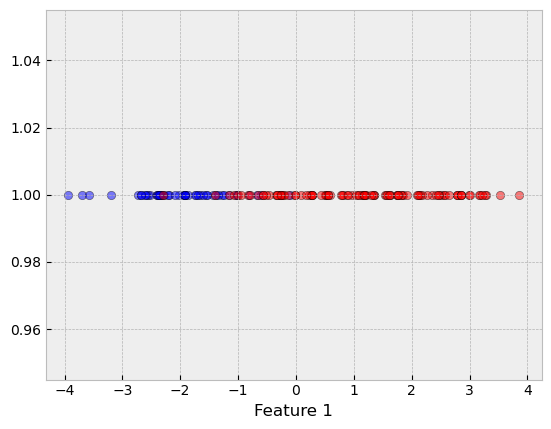

In [3]:
mean1 = [-2]
mean2 = [1]
var1 = [1]
var2 = [2]
N1 = 50 # C1 - blue
N2 = 100 # C2 - red

data, labels = generateData(mean1, mean2, var1, var2, N1, N2)

In [4]:
def drawMAP(data, labels):
    
    #### Estimate parameters (MLE solution)
    # Means
    mu1 = np.mean(data[labels==1]) 
    mu2 = np.mean(data[labels==2])
    
    # Variances
    var1 = np.cov(data[labels==1])
    var2 = np.cov(data[labels==2])
    
    #### Estimate Prior Probabilities - relative frequency
    N = len(data)
    N1 = np.sum(labels==1)
    N2 = N - N1
    p1 = N1/N # prior probability for C1
    p2 = N2/N # prior probability for C2
    
    #### Define data likelihoods 
    G1=stats.norm(loc=mu1,scale=np.sqrt(var1)) # P(x|C1)
    G2=stats.norm(loc=mu2,scale=np.sqrt(var2)) # P(x|C2)
    x=np.linspace(-6,6,1001)
        
    #### Plot the weighted densities
    # these are proportional to the posteriors
    plt.figure(figsize=(10,5))
    plt.plot(x,p1*G1.pdf(x),label='$f_X(x|C_1)P(C_1)$')
    plt.plot(x,p2*G2.pdf(x),label='$f_X(x|C_2)P(C_2)$')
    
    #### Determine the regions where the posterior for deciding C1 
    # and the posterior for deciding C2
    R1=x[np.where(p1*G1.pdf(x)>= p2*G2.pdf(x))]
    R2=x[np.where(p1*G1.pdf(x)< p2*G2.pdf(x))]

    # Fill under the regions found above
    plt.fill_between(R1,p1*G1.pdf(R1),alpha=0.3,label='Decide C1')
    plt.fill_between(R2,p2*G2.pdf(R2),alpha=0.3,label='Decide C2')
    plt.scatter(data[labels==1], -0.01*np.ones(N1), c='b', alpha=0.5, edgecolors='k')
    plt.scatter(data[labels==2], -0.01*np.ones(N2), c='r', alpha=0.5, edgecolors='k')
    plt.legend()
    
    # Print the MAP threshold
    print('MAP decision threshold to decide C2 is >',round(R2[0],2))

MAP decision threshold to decide C2 is > -0.84


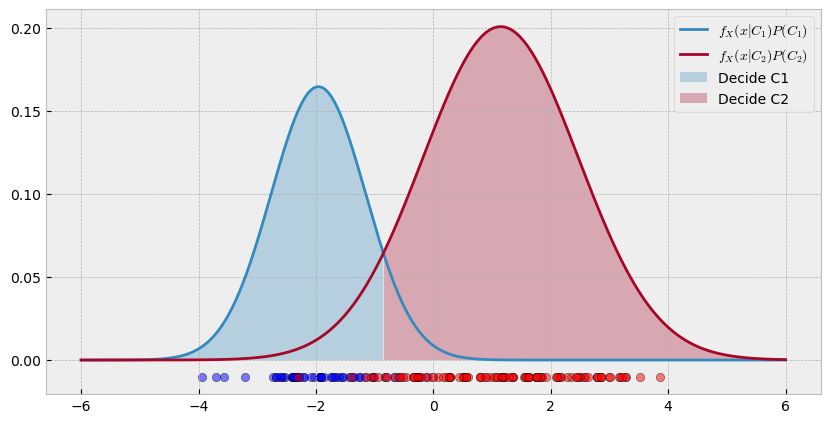

In [5]:
drawMAP(data,labels)

## Case 2: Multivariate Data Likelihood

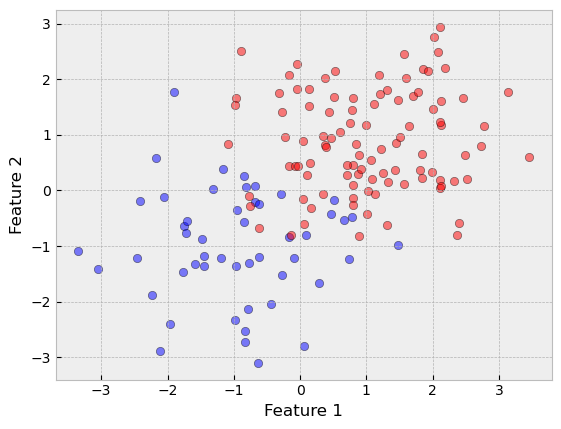

In [6]:
mean1 = [-1, -1]
mean2 = [1, 1]
cov1 = [[1,0],[0,1]]
cov2 = [[1,0],[0,1]]
N1 = 50
N2 = 100

data, labels = generateData(mean1, mean2, cov1, cov2, N1, N2)

In the data we generated above, we have a "red" class and a "blue" class. When we are given a test sample, we will want to assign the label of red or blue.

We can compute the **posterior probability** for class $C_1$ as follows:

\begin{align*}
P(C_1|x) = \frac{P(x|C_1)P(C_1)}{P(x)}
\end{align*}

Understanding that the two classes, red and blue, form a partition of all possible classes, then we can utilize the *Law of Total Probability*, and obtain:

\begin{align*}
P(C_1|x)=\frac{P(x|C_1)P(C_1)}{P(x|C_1)P(C_1) + P(x|C_2)P(C_2)}
\end{align*}

Similarly, we can compute the posterior probability for class $C_2$:

\begin{align*}
P(C_2|x) = \frac{P(x|C_2)P(C_2)}{P(x|C_1)P(C_1) + P(x|C_2)P(C_2)}
\end{align*}

Note that $P(C_1|x) + P(C_2|x) = 1$.

# The Naive Bayes Classifier

Therefore, for a given test point $\mathbf{x}^*$, our decision rule is:

\begin{align*}
P(C_1|\mathbf{x}^*) \underset{C_2}{\overset{C_1}{\gtrless}} P(C_2|\mathbf{x}^*)
\end{align*}

Using the Bayes' rule, we can further rewrite it as:
\begin{align*}
\frac{P(\mathbf{x}^*|C_1)P(C_1)}{P(\mathbf{x}^*)} &\underset{C_2}{\overset{C_1}{\gtrless}} \frac{P(\mathbf{x}^*|C_2)P(C_2)}{P(\mathbf{x}^*)} \\
\iff P(\mathbf{x}^*|C_1)P(C_1) &\underset{C_2}{\overset{C_1}{\gtrless}} P(\mathbf{x}^*|C_2)P(C_2)
\end{align*}

We assign $\mathbf{x}^*$ as class 1 if $p(\mathbf{x}^*|C_1) p(C_1) > p(\mathbf{x}^*|C_2) p(C_2)$, or assign $\mathbf{x}^*$ to class 2 if $p(\mathbf{x}^*|C_1) p(C_1) < p(\mathbf{x}^*|C_2) p(C_2)$.

This defines the **Naive Bayes Classifier**.

## Training a Generative Classifier

* So, **to train the classifier**, what we need to do is to choose the parametric forms and calculate the parameters for $P(x|C_1)$, $P(x|C_2)$, $P(C_1)$ and $P(C_2)$, using the training data.

For example, we can assume that the data samples coming from either $C_1$ and $C_2$ are distributed according to Gaussian distributions. In this case, 

$$P(x|C_k) = \frac{1}{(2\pi)^{d/2} |\Sigma_k|^{1/2}}\exp\left\{-\frac{1}{2}(\mathbf{x}-\mathbf{\mu}_k)^T\Sigma_k^{-1}(\mathbf{x}-\mathbf{\mu}_k)\right\}, \forall k=\{1,2\}$$

* We can consider any distributional form we want.

What about the $P(C_1)$ and $P(C_2)$?

* We can consider the relative frequency of each class, that is, $P(C_i) = \frac{N_i}{N}$, where $N_i$ is the number of points in class $C_i$ and $N$ is the total number of samples.

___

## MLE Parameter Estimation Steps

For simplification, let's consider the covariance matrix $\Sigma_k$ for $k=1,2$ to be **isotropic** matrices, that is, the covariance matrix is diagonal and the element along the diagonal is the same, or: $\Sigma_k = \sigma_k^2\mathbf{I}$.

* What are the parameters? The mean and covariance of the Gaussian distribution for both classes.

Given the assumption of the Gaussian form, how would you estimate the parameters for $p(x|C_1)$ and $p(x|C_2)$? We can use **maximum likelihood estimate** for the mean and covariance, because we are looking for the parameters of the distributions that *maximize* the data likelihood!

**Assumption:** Assuming the classes follow a (bivariate or 2-D) Gaussian distribution and, for simplicity, let's assume the covariance matrices are **isotropic**, that is, $\Sigma_k = \sigma^2_k \mathbf{I}$.

The MLE steps for parameter estimation are:

1. Write down the observed data likelihood, $\mathcal{L}^0$

\begin{align*}
\mathcal{L}^0 &= P(x_1,x_2,\dots,x_N|C_k)\\
&= \prod_{n=1}^N P(x_n|C_k),\text{ data samples are i.i.d.} \\
&= \prod_{n=1}^N \frac{1}{(2\pi)^{d/2} |\Sigma|^{1/2}} \exp\left\{-\frac{1}{2}(x_n-\mu_k)^T\Sigma_k^{-1}(x_n-\mu_k)\right\}\\
&= \prod_{n=1}^N \frac{1}{(2\pi)^{d/2} |\sigma_k^2 \mathbf{I}|^{1/2}} \exp\left\{-\frac{1}{2\sigma_k^2}(x_n-\mu_k)^T\mathbf{I}(x_n-\mu_k)\right\}\\
&= \prod_{n=1}^N \frac{1}{(2\pi)^{d/2} (\sigma_k^2)^{d/2}} \exp\left\{-\frac{1}{2\sigma_k^2}(x_n-\mu_k)^T(x_n-\mu_k)\right\}
\end{align*}

where $d$ is the dimensionality of the data space.

2. Take the log-likelihood, $\mathbf{L}$. This *trick* helps in taking derivatives.

\begin{align*}
\mathcal{L} &= \ln\left(\mathcal{L}^0\right) \\
&= \sum_{n=1}^N \left( -\frac{d}{2}\ln 2\pi - \frac{d}{2}\ln\sigma_k^2 - \frac{1}{2\sigma_k^2}(x_n-\mu_k)^T(x_n-\mu_k) \right)
\end{align*}

3. Take the derivative of the log-likelihood function with respect to the parameters of interest. For Gaussian distribution they are the mean and covariance.

\begin{align*}
\frac{\partial \mathcal{L}}{\partial \mu_k} &= 0\\
\sum_{n\in C_k} \frac{1}{\sigma_k^2} (x_n - \mu_k) &= 0\\
\sum_{n\in C_k} (x_n - \mu_k) &= 0 \\
\sum_{n\in C_k} x_n - \sum_{n\in C_k} \mu_k &= 0 \\
\sum_{n\in C_k} x_n - N_k \mu_k &= 0
\end{align*}

$$\mu_k = \frac{1}{N_k} \sum_{n\in C_k} x_n$$

This is the sample mean for each class. And,

\begin{align*}
\frac{\partial \mathcal{L}}{\partial \sigma_k^2} &= 0\\
\sum_{n\in C_k} -\frac{d}{2\sigma_k^2} + \frac{2(x_n - \mu_k)^T(x_n - \mu_k)}{(2\sigma_k^2)^2} &=0 \\
\sum_{n\in C_k} -d + \frac{(x_n - \mu_k)^T(x_n - \mu_k)}{\sigma_k^2} &=0 \\
\frac{\sum_{n\in C_k}(x_n - \mu_k)^T(x_n - \mu_k)}{\sigma_k^2} &=dN_k
\end{align*}

$$\sigma_k^2 = \frac{\sum_{n\in C_k}(x_n - \mu_k)^T(x_n - \mu_k)}{dN_k}$$

This is the sample variance for each class. Then we can create $\Sigma_k = \sigma_k^2 \mathbf{I}$, which is the (biased) sample covariance for each class.

In practice, if we want to estimate an entire covariance matrix, we would have to take the derivative of the log-likelihood function with respect to every entry in the covariance matrix. Covariance matrices are symmetric, so we only need to determine the upper (or lower) half of the covariance matrix.

We can determine the values for $p(C_1)$ and $p(C_2)$ from the number of data points in each class:

$$p(C_k) = \frac{N_k}{N}$$

where $N$ is the total number of data points.

In [33]:
#### Estimate parameters (with MLE solutions)
# Means
mu1 = np.mean(data[labels==1], axis=0)
print('Mean of Class 1: ', mu1)
mu2 = np.mean(data[labels==2], axis=0)
print('Mean of Class 2: ', mu2)

# Covariances - in this example we are showing the case where we estimate the full covariance
cov1 = np.cov(data[labels==1,:].T) # np.cov expects input to be D-by-N
print('Covariance of Class 1: ',cov1)
cov2 = np.cov(data[labels==2, :].T)
print('Covariance of Class 2: ',cov2)

#### Estimate Prior Probabilities
N = N1+N2
p1 = N1/N
print('Probability of  Class 1: ',p1)
p2 = N2/N
print('Probability of  Class 2: ',p2)

Mean of Class 1:  [-0.96618319 -1.00577703]
Mean of Class 2:  [1.01999935 0.8862981 ]
Covariance of Class 1:  [[ 1.04817502 -0.01805292]
 [-0.01805292  0.98812843]]
Covariance of Class 2:  [[1.00063834 0.06501556]
 [0.06501556 0.82011685]]
Probability of  Class 1:  0.3333333333333333
Probability of  Class 2:  0.6666666666666666


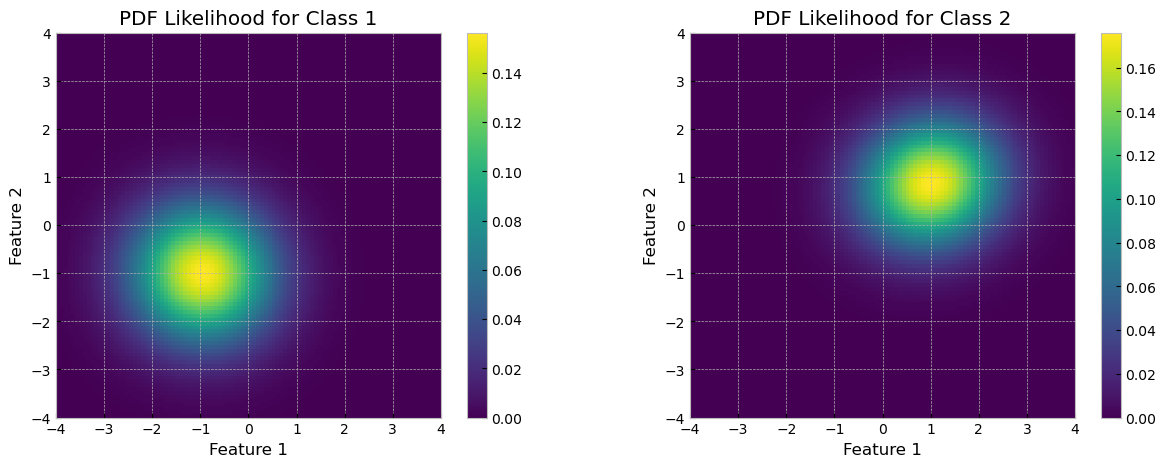

In [42]:
# Compute a grid of values for x and y 
grid = 4
x = np.linspace(-grid, grid, 100)
y = np.linspace(-grid, grid, 100)
xm, ym = np.meshgrid(x, y)
X = np.flip(np.dstack([xm,ym]),axis=0) # grid of values

# Let's plot the probabaility density function (pdf) for each class
y1 = stats.multivariate_normal.pdf(X, mean=mu1, cov=cov1) #P(x|C1) - data likelihood for C1
y2 = stats.multivariate_normal.pdf(X, mean=mu2, cov=cov2) #P(x|C2)

fig =plt.figure(figsize=(15,5))
fig.add_subplot(1,2,1)
plt.imshow(y1, extent=[-grid,grid,-grid,grid])
plt.colorbar()
plt.xlabel('Feature 1'); plt.ylabel('Feature 2')
plt.title('PDF Likelihood for Class 1')

fig.add_subplot(1,2,2)
plt.imshow(y2, extent=[-grid,grid,-grid,grid])
plt.colorbar()
plt.xlabel('Feature 1'); plt.ylabel('Feature 2')
plt.title('PDF Likelihood for Class 2');

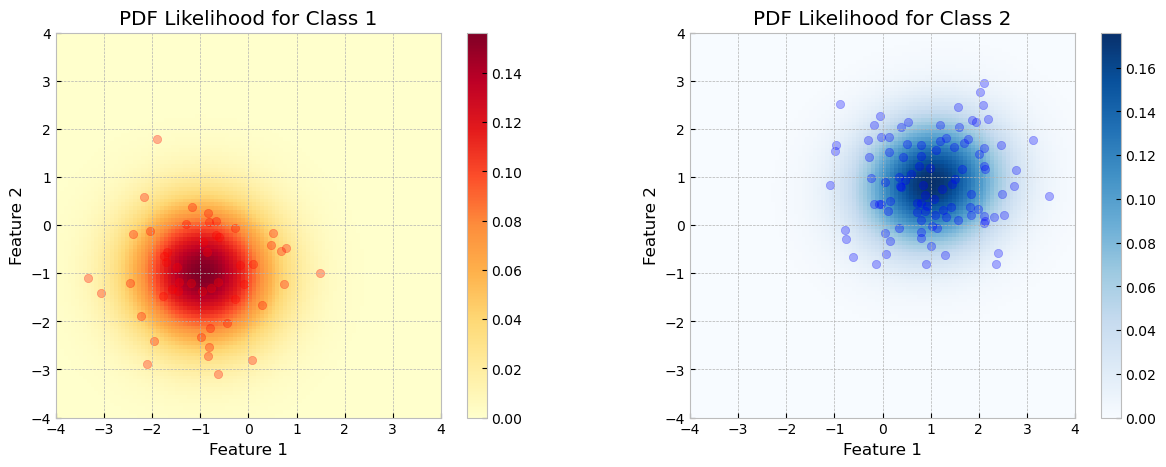

In [43]:
fig =plt.figure(figsize=(15,5))
fig.add_subplot(1,2,1)
plt.scatter(data[labels==1,0], data[labels==1,1], c='r',alpha=0.3)
plt.imshow(y1, extent=[-grid,grid,-grid,grid],cmap='YlOrRd')
plt.colorbar()
plt.xlabel('Feature 1'); plt.ylabel('Feature 2')
plt.title('PDF Likelihood for Class 1')

fig.add_subplot(1,2,2)
plt.scatter(data[labels==2,0], data[labels==2,1], c='b',alpha=0.3)
plt.imshow(y2, extent=[-grid,grid,-grid,grid], cmap='Blues')
plt.colorbar()
plt.xlabel('Feature 1'); plt.ylabel('Feature 2')
plt.title('PDF Likelihood for Class 2');

In [44]:
cov1

array([[ 1.04817502, -0.01805292],
       [-0.01805292,  0.98812843]])

In [45]:
cov2

array([[1.00063834, 0.06501556],
       [0.06501556, 0.82011685]])

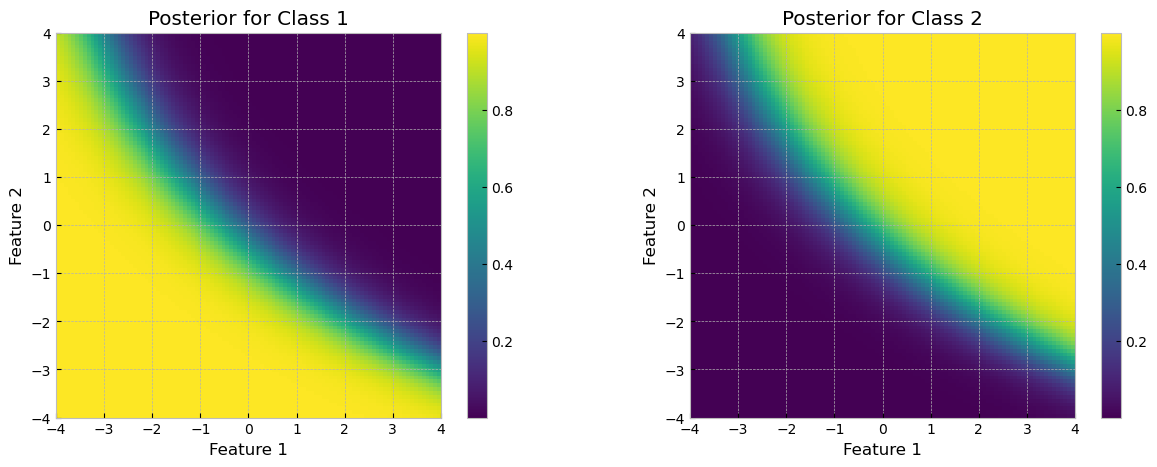

In [46]:
# Let's take a look at the posterior distributions: they represent our classification decision
pos1 = (y1*p1)/(y1*p1 + y2*p2) # P(C1|x) - posterior probability
pos2 = (y2*p2)/(y1*p1 + y2*p2) # P(C2|x)

fig =plt.figure(figsize=(15,5))
fig.add_subplot(1,2,1)
plt.imshow(pos1, extent=[-grid,grid,-grid,grid])
plt.colorbar()
plt.xlabel('Feature 1'); plt.ylabel('Feature 2')
plt.title('Posterior for Class 1')

fig.add_subplot(1,2,2)
plt.imshow(pos2, extent=[-grid,grid,-grid,grid])
plt.colorbar()
plt.xlabel('Feature 1'); plt.ylabel('Feature 2')
plt.title('Posterior for Class 2');

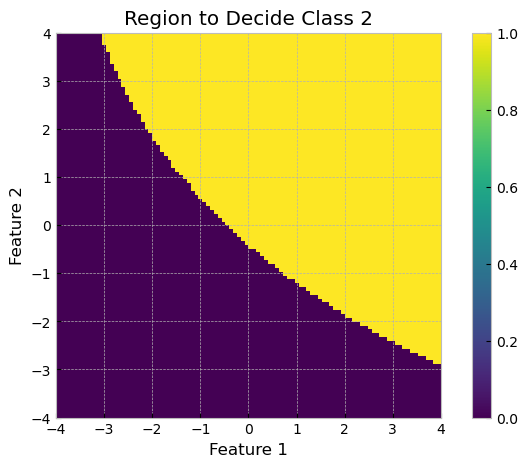

In [47]:
# Look at the decision boundary for deciding Class 2

plt.figure(figsize=(8,5))
plt.imshow(pos2>pos1, extent=[-grid,grid,-grid,grid])
plt.colorbar()
plt.xlabel('Feature 1'); plt.ylabel('Feature 2')
plt.title('Region to Decide Class 2');

* Let's use this classifier to predict the class label for point $[1,1]$:

In [48]:
x = [1,1]

# Data Likelihoods
y1_newPoint = stats.multivariate_normal.pdf(x, mean=mu1, cov=cov1) #P(x|C1)
y2_newPoint = stats.multivariate_normal.pdf(x, mean=mu2, cov=cov2) #P(x|C2)

print('Data likelihoods:')
print('P(x|C1) = ', y1_newPoint)
print('P(x|C2) = ', y2_newPoint,'\n')

# Posterior Probabilities
y1_pos = (y1_newPoint*p1)/(y1_newPoint*p1+y2_newPoint*p2) #P(C1|x)
y2_pos = (y2_newPoint*p2)/(y1_newPoint*p1+y2_newPoint*p2) #P(C2|x)

print('Posterior probabilities:')
print('P(C1|x) = ', y1_pos)
print('P(C2|x) = ', y2_pos,'\n')

if y1_pos > y2_pos:
    print('x = ',x,' belongs to class 1')
else:
    print('x = ',x,' belongs to class 2')

Data likelihoods:
P(x|C1) =  0.0030121746315068636
P(x|C2) =  0.17468612554586568 

Posterior probabilities:
P(C1|x) =  0.008547978887899595
P(C2|x) =  0.9914520211121004 

x =  [1, 1]  belongs to class 2


* What about $x=[4,4]$?

In [49]:
x = [4,4]

# Data Likelihoods
y1_newPoint = stats.multivariate_normal.pdf(x, mean=mu1, cov=cov1) #P(x|C1)
y2_newPoint = stats.multivariate_normal.pdf(x, mean=mu2, cov=cov2) #P(x|C2)

print('Data likelihoods:')
print('P(x|C1) = ', y1_newPoint)
print('P(x|C2) = ', y2_newPoint,'\n')

# Posterior Probabilities
y1_pos = (y1_newPoint*p1)/(y1_newPoint*p1+y2_newPoint*p2) #P(C1|x)
y2_pos = (y2_newPoint*p2)/(y1_newPoint*p1+y2_newPoint*p2) #P(C2|x)

print('Posterior probabilities:')
print('P(C1|x) = ', y1_pos)
print('P(C2|x) = ', y2_pos,'\n')

if y1_pos > y2_pos:
    print('x = ',x,' belongs to class 1')
else:
    print('x = ',x,' belongs to class 2')

Data likelihoods:
P(x|C1) =  2.4362561250239512e-12
P(x|C2) =  1.1203209897253184e-05 

Posterior probabilities:
P(C1|x) =  1.0873026045537682e-07
P(C2|x) =  0.9999998912697395 

x =  [4, 4]  belongs to class 2


---

# Solving for the Discriminant Function

Classification can also be seen as implementing a set of **discriminant functions**, $g_i(x), i=1,\dots, K$, such that we

$$\text{Choose} \;\; C_i \;\; \text{if} \;\; g_i(x) = \max_k g_k(x)$$

where $g_i(\mathbf{x}) = \ln(P(C_i|\mathbf{x})) = \ln(P(\mathbf{x}|C_i)P(C_i))$.

When there are **two classes** ($C_1$ and $C_2$), we have the **Bayesian decision rule**

\begin{align*}
\text{Choose} \;\; C_1 \;\; \text{if} \;\; & P(C_1|x) > P(C_2|x) \\
\text{Choose} \;\; C_1 \;\; \text{if} \;\; & P(x|C_1)P(C_1) > P(x|C_2)P(C_2)\\
\text{Choose} \;\; C_1 \;\; \text{if} \;\; & \ln(P(x|C_1)P(C_1)) > \ln(P(x|C_2)P(C_2))\\
\text{Choose} \;\; C_1 \;\; \text{if} \;\; & g_1(x) > g_2(x)\\
\text{Choose} \;\; C_1 \;\; \text{if} \;\; & g_1(x)-g_2(x) > 0
\end{align*}


When there are **two classes**, we can define a single discriminant

$$g(\mathbf{x}) = g_1(\mathbf{x}) - g_2(\mathbf{x})$$

and we

$$\text{Choose} \begin{cases}C_1 & \text{if} \; g(\mathbf{x})>0\\ C_2 & \text{otherwise}\end{cases}$$

---

## Exercise 1

Explicitly calculate the decision boundary for the two-class two-dimensional data. Assume that the data likelihood for each class is a bivariate Gaussian distribution

$$P(\mathbf{x}|C_i) = \frac{1}{(2\pi)^{d/2}|\Sigma_i|^{1/2}} \exp\left\{-\frac{1}{2}(\mathbf{x}-\mu_i)^T\Sigma_i^{-1}(\mathbf{x}-\mu_i)\right\}$$

where 

$$\mu_1 =\begin{bmatrix}3\\6\end{bmatrix}, \;\;\; \mu_2 =\begin{bmatrix}3\\-2\end{bmatrix}, \;\;\; \Sigma_1=\begin{bmatrix}1/2 & 0\\0 &2\end{bmatrix}, \;\;\; \Sigma_2=\begin{bmatrix}2 & 0\\0 &2\end{bmatrix}$$

The inverse matrices are

$$\Sigma_1^{-1}=\begin{bmatrix}2 & 0\\0 &1/2\end{bmatrix}, \;\;\; \Sigma_2^{-1}=\begin{bmatrix}1/2 & 0\\0 &1/2\end{bmatrix}$$

Assume equal prior probabilities $P(C_1)=P(C_2)=\frac{1}{2}$.

1. Compute the discriminant function (decision function).

**Answer in board notes.**

In [50]:
mu1 = [3, 6]
mu2 = [3, -2]

Sigma1 = np.array([[0.5,0],[0,2]])
Sigma2 = np.array([[2,0],[0,2]])

p1 = 0.5
p2 = 1-p1

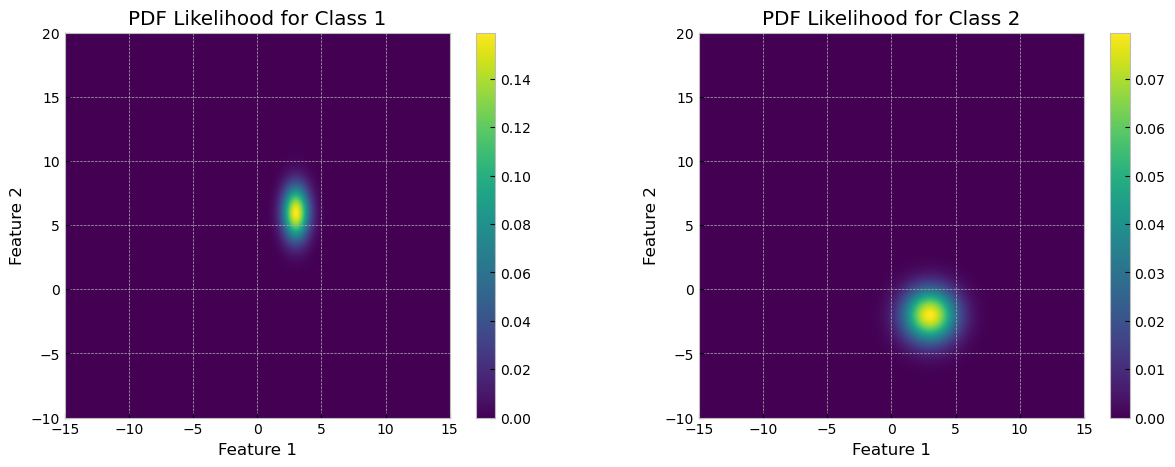

In [51]:
# Compute a grid of values for x and y 
gridx = 15
gridy = 20
x = np.linspace(-gridx, gridx, 500)
y = np.linspace(-10, gridy, 500)
xm, ym = np.meshgrid(x, y)
X = np.flip(np.dstack([xm,ym]),axis=0) # grid of values

# Let's plot the probabaility density function (pdf) for each class
y1 = stats.multivariate_normal.pdf(X, mean=mu1, cov=Sigma1) #P(x|C1) - data likelihood for C1
y2 = stats.multivariate_normal.pdf(X, mean=mu2, cov=Sigma2) #P(x|C2)

fig =plt.figure(figsize=(15,5))
fig.add_subplot(1,2,1)
plt.imshow(y1, extent=[-gridx,gridx,-10,gridy])
plt.colorbar()
plt.xlabel('Feature 1'); plt.ylabel('Feature 2')
plt.title('PDF Likelihood for Class 1')

fig.add_subplot(1,2,2)
plt.imshow(y2, extent=[-gridx,gridx,-10,gridy])
plt.colorbar()
plt.xlabel('Feature 1'); plt.ylabel('Feature 2')
plt.title('PDF Likelihood for Class 2');

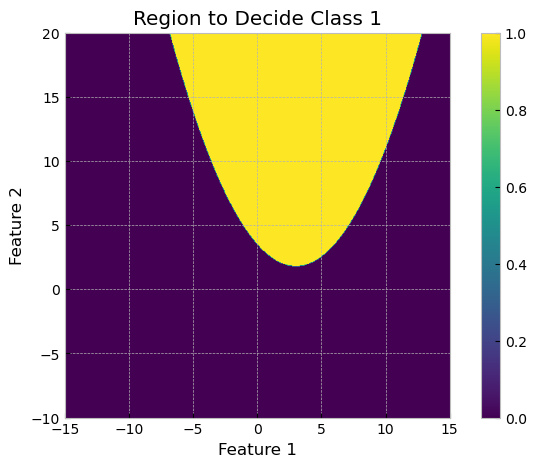

In [52]:
# Let's take a look at the posterior distributions: they represent our classification decision
pos1 = (y1*p1)/(y1*p1 + y2*p2) # P(C1|x) - posterior probability
pos2 = (y2*p2)/(y1*p1 + y2*p2) # P(C2|x)

# Look at the decision boundary:
plt.figure(figsize=(8,5))
plt.imshow(pos1>pos2, extent=[-gridx,gridx,-10,gridy])
plt.colorbar()
plt.xlabel('Feature 1'); plt.ylabel('Feature 2')
plt.title('Region to Decide Class 1');

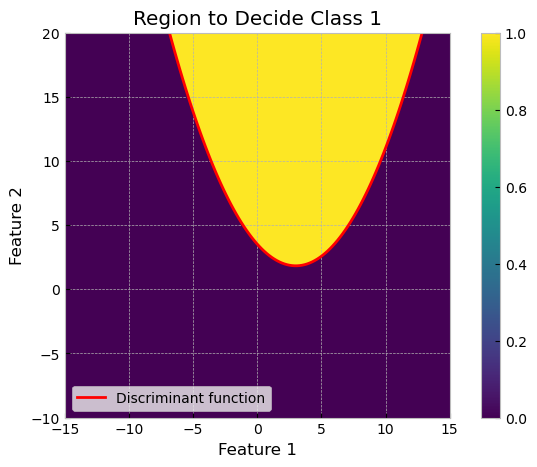

In [53]:
# Compare with the one derived on the blackboard - they are the same, as expected

x1 = np.linspace(-6.8,12.8, 100)

plt.figure(figsize=(8,5))
plt.imshow(pos1>pos2, extent=[-gridx,gridx,-10,gridy])
plt.plot(x1, 3.514 - 1.125*x1 + 0.1875*x1**2, 'r', label='Discriminant function')
plt.colorbar(); plt.legend()
plt.xlabel('Feature 1'); plt.ylabel('Feature 2')
plt.title('Region to Decide Class 1');

---
---
---